# Notebook for conducting the main sizing of the 5 design options for trade-off

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy.typing as nt
import aerosandbox.numpy as np

# Add the 'src' directory to the python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from src.Sizing_Loop.SizingForTradeoff import SizingForTradeoff, DesignOptionState

## Generating the initial values and decisions for design options

In [2]:
sizing_for_tradeoff = SizingForTradeoff()

for configuration in sizing_for_tradeoff.configurations:
    print()
    print(configuration.name)
    print("high wing" if np.isclose(configuration.wing_interference_factor, 1.) else "low wing")
    print("movable wing port" if configuration.main_wing_x_movable else "fixed wing port")
    print("canard capability" if configuration.canard_capability else "no canard port")
    print("sideways extending landing gear" if configuration.landing_gear_sideways_extendable else "downwards extending landing gear")


HUG-CFG-301
low wing
movable wing port
canard capability
sideways extending landing gear

HUG-CFG-302
high wing
fixed wing port
no canard port
downwards extending landing gear

HUG-CFG-303
high wing
fixed wing port
canard capability
sideways extending landing gear

HUG-CFG-304
high wing
movable wing port
canard capability
downwards extending landing gear

HUG-CFG-305
high wing
movable wing port
canard capability
sideways extending landing gear


## Specifying the settings of the analysis

In [3]:
sizing_for_tradeoff.accumulate_steps()

In [4]:
def tracked_varaibles(state:DesignOptionState) -> nt.NDArray[np.float64]:
    return np.array([
        state.iterable.aircraft_parameters.total_mass
    ])

In [5]:
n_iterations = 6

## Running the analysis

In [6]:
sizing_results = sizing_for_tradeoff.size_options_for_tradeoff(n_iterations, tracked_varaibles)

print(sizing_results)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5861988017451497
            Iterations: 13
            Function evaluations: 50
            Gradient evaluations: 12
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5420154841298582
            Iterations: 15
            Function evaluations: 99
            Gradient evaluations: 14
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5405382299643596
            Iterations: 29
            Function evaluations: 180
            Gradient evaluations: 28
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5410780034535966
            Iterations: 24
            Function evaluations: 92
            Gradient evaluations: 22
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.541004886665093
            Iterations: 13
            Function eva

## Postprocessing the analysis

[[ 50.         252.26986241 190.83347775 196.12262739 196.75847296
  196.66769969 196.67983721]]
[[ 50.         252.26986241 187.4586959  190.62672558 193.41264483
  193.47551982 193.46454899]]
[[ 50.         252.26986241 187.13485478 189.75326247 192.6023774
  193.11318868 193.04116459]]
[[ 50.         252.26986241 187.4586959  190.62672558 193.41264483
  193.47551982 193.46454899]]
[[ 50.         252.26986241 187.13485478 189.75326247 192.6023774
  193.11318868 193.04116459]]


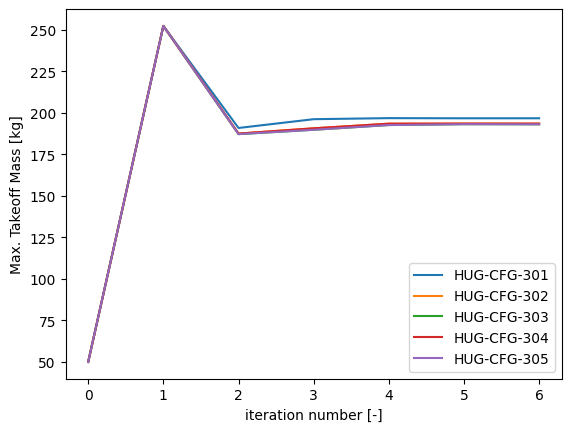

In [7]:
for design_option, convergence_history in sizing_results:
    print(convergence_history)
    print(design_option)
    plt.plot(list(range(n_iterations+1)), convergence_history[0], label=design_option.state.fixed.choices.name)
    
plt.ylabel("Max. Takeoff Mass [kg]")
plt.xlabel("iteration number [-]")
plt.legend()

In [ ]:
for design_option, convergence_history in sizing_results:
    print()
    print(design_option.state.fixed.choices.name)
    # print(f"Landing gear nose x: {design_option.state.iterable.landing_gear.x_nose_lg}")
    # print(f"Landing gear main x: {design_option.state.iterable.landing_gear.x_main_lg}")
    # print(f"Main gear y: {design_option.state.iterable.landing_gear.y_main_lg}")
    # print(f"landing gear height: {design_option.state.iterable.landing_gear.length_z}")
    print(f"Fuselage length: {design_option.state.total_fuselage_length()}")
    print(f"Fus L1 {design_option.state.fixed.assumptions.fuselage_length1}")
    print(f"Fus L2 {design_option.state.fixed.assumptions.fuselage_length2}")
    print(f"Fus L3 {design_option.state.fixed.assumptions.fuselage_length3}")
    print(f"Wingspan main wing: {design_option.state.iterable.lifting_surfaces[0].span}")
    print(f"aspect ratio main wing: {design_option.state.iterable.lifting_surfaces[0].aspect_ratio}")
    print(f"MTOM: {design_option.state.iterable.aircraft_parameters.total_mass}")


HUG-CFG-301
Fuselage length: 1.935828085104722
Fus L1 0.31131738210748455
Fus L2 0.9905553067056326
Fus L3 0.6339553962916049
Wingspan main wing: 6.180258465825011
aspect ratio main wing: 27.0
MTOM: 196.6798372088979

HUG-CFG-302
Fuselage length: 1.9034724921941808
Fus L1 0.3061139972826899
Fus L2 0.9739990822631042
Fus L3 0.6233594126483867
Wingspan main wing: 6.128392149027932
aspect ratio main wing: 27.0
MTOM: 193.46454898891432

HUG-CFG-303
Fuselage length: 1.8992225594169287
Fus L1 0.305430528561202
Fus L2 0.9718244090583699
Fus L3 0.6219676217973568
Wingspan main wing: 6.121546815300913
aspect ratio main wing: 27.0
MTOM: 193.04116459413626

HUG-CFG-304
Fuselage length: 1.9034724921941808
Fus L1 0.3061139972826899
Fus L2 0.9739990822631042
Fus L3 0.6233594126483867
Wingspan main wing: 6.128392149027932
aspect ratio main wing: 27.0
MTOM: 193.46454898891432

HUG-CFG-305
Fuselage length: 1.8992225594169287
Fus L1 0.305430528561202
Fus L2 0.9718244090583699
Fus L3 0.6219676217973568
